In [1]:
%cd ../../

/leonardo_work/IscrC_LR4LSDS/encoderops


In [2]:
import torch
from dotenv import load_dotenv
from pathlib import Path
from src.model import EvolutionOperator
from src.data import DESRESDataModule
from src.configs import TrainerArgs, DESRESDataArgs # noqa
from huggingface_hub import hf_hub_download
from torch_geometric.loader import DataLoader
from loguru import logger
# from dataclasses import asdict
# import linear_operator_learning as lol
import matplotlib.pyplot as plt
#from src.data import mdtraj_load
import numpy as np
import os
#from src.utils import compute_descriptors
import pandas as pd
# import wandb

# Assume there's a .env file on the root of the repo where "DATA_PATH" is defined
load_dotenv()

True

In [15]:
baseline_runs: dict[str, str] = {
    "l2": "9dgu7e6f",
    "dpnets": "1104ltut",
    "vampnets": "oy1cfh9i",
    "joint_l2": "03lvauoh", #!! To double-check
    "seq_l2": "860pfnf9"
}

In [16]:
ckpt_path = lambda baseline: Path(f"logs/encoderops-2JOF/{baseline_runs[baseline]}/checkpoints/last.ckpt")

In [17]:
@torch.no_grad()
def get_timescales(baseline):
    print(f"Retrieving {baseline}")
    model = EvolutionOperator.load_from_checkpoint(ckpt_path(baseline))
    lagtime_ns = 100
    transfer_operator = model.get_transfer_operator()
    operator_eigs = torch.linalg.eigvals(transfer_operator).numpy(force=True)
    timescales = np.sort((1 / -np.log(np.abs(operator_eigs))) * lagtime_ns)[::-1]
    return timescales

In [19]:
timescales = {k: get_timescales(k) for k in baseline_runs.keys()}

Retrieving l2
Retrieving dpnets
Retrieving vampnets
Retrieving joint_l2
Retrieving seq_l2


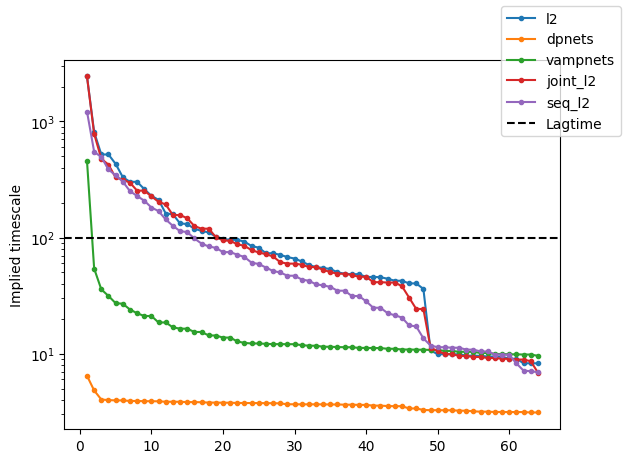

In [25]:
fig, ax = plt.subplots()
for k, ts in timescales.items():
    x = range(1, len(ts) + 1)
    ax.plot(x, ts, '.-', label = k)
ax.set_yscale('log')
ax.set_ylabel('Implied timescale')
ax.axhline(y=100, color='k', linestyle='--', label="Lagtime")
fig.legend()